# Feature Engineering for Classical ML Models

- Add a proper introduction

In [1]:
%load_ext autoreload
%autoreload 2

import os
# Force Transformers to skip TensorFlow/Keras to avoid Keras 3 incompat error when importing sentence-transformers
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("USE_TF", "0")

import pandas as pd
import seaborn as sns

from dota_oracle_common.postgresql import DatabaseManager

from dotenv import load_dotenv

pd.set_option("display.max_columns", 100)
pd.set_option('display.max_rows', 50)

# Load env vars after setting defaults
env = load_dotenv()

In [2]:

# disable Loki logging for the local session
os.environ["ENABLE_LOKI_LOGGING"] = "false"

# Create a database session factory for this notebook session
local_session = DatabaseManager.get_session_factory()

2025-09-29 10:32:48,606 - dota_oracle_common.postgresql - INFO - Creating database engine with pool_size=10 and max_overflow=5
2025-09-29 10:32:48,687 - dota_oracle_common.postgresql - INFO - Successfully initialized database for 'dota2' at localhost


# 1. Establishing a baseline

In [ ]:
from lib.data_management import load_pro_matches_parquet, save_pro_matches_parquet, load_match_tables_jsonl, save_match_tables_jsonl

In [107]:
df = load_pro_matches_parquet("../data/pro_match_dataset_.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40525 entries, 0 to 40524
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   match_id     40525 non-null  int64              
 1   patch        40525 non-null  object             
 2   radiant_win  40525 non-null  bool               
 3   start_time   40525 non-null  datetime64[ns, UTC]
dtypes: bool(1), datetime64[ns, UTC](1), int64(1), object(1)
memory usage: 989.5+ KB


In [105]:
all_match_tables = load_match_tables_jsonl("../data/pro_match_tables.jsonl")
all_match_tables

[MatchTable(match_id=7875299320, leagueid=16059, radiant_name='Dark Rebellion', radiant_team_id=9426115, dire_name='Shadow Avengers', dire_team_id=9425660, start_time=datetime.datetime(2024, 8, 1, 7, 31, 59, tzinfo=datetime.timezone.utc), duration=1663.0, slot_0_hero_id=55, slot_1_hero_id=18, slot_2_hero_id=72, slot_3_hero_id=74, slot_4_hero_id=68, slot_128_hero_id=69, slot_129_hero_id=44, slot_130_hero_id=96, slot_131_hero_id=7, slot_132_hero_id=121, slot_0_account_id=412910858, slot_1_account_id=183270733, slot_2_account_id=176158708, slot_3_account_id=1068676453, slot_4_account_id=1090568489, slot_128_account_id=1621602027, slot_129_account_id=1621469892, slot_130_account_id=371126611, slot_131_account_id=1621011351, slot_132_account_id=1621624406),
 MatchTable(match_id=7875309074, leagueid=16312, radiant_name='Dominatrix', radiant_team_id=9332046, dire_name='Marvelous Warriors', dire_team_id=8864178, start_time=datetime.datetime(2024, 8, 1, 7, 42, 33, tzinfo=datetime.timezone.utc),

<Axes: xlabel='patch', ylabel='count'>

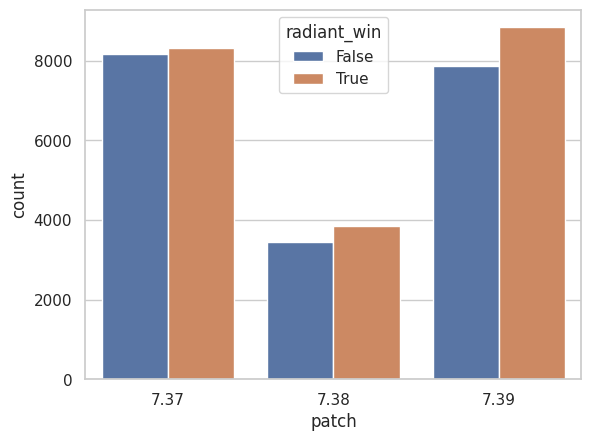

In [108]:
sns.countplot(data=df, x='patch', hue='radiant_win')

In [109]:
percentage_counts_by_patch = df.groupby('patch')['radiant_win'].value_counts(normalize=True)
percentage_counts_all = df['radiant_win'].value_counts(normalize=True)

percentage_counts_by_patch, percentage_counts_all

(patch  radiant_win
 7.37   True           0.504455
        False          0.495545
 7.38   True           0.526575
        False          0.473425
 7.39   True           0.528758
        False          0.471242
 Name: proportion, dtype: float64,
 radiant_win
 True     0.51847
 False    0.48153
 Name: proportion, dtype: float64)

**Data Source:** The dataset consists of approximately 40,000 professional Dota 2 matches, across 3 most recent patches (7.37, 7.38, 7.39) loaded directly from a pre-processed database. All the important fields which will be used for feature engineering are present. 

**Target Variable Analysis:** The most critical finding from the EDA was the distribution of the target variable, radiant_win. The dataset is almost perfectly balanced, with Radiant winning approximately 50-52% of the time on average across all patches. This is consistent with the known, subtle map advantage which Radiant Side has historically over many patches.

**Establishing the Baseline:** This balance provides a clear, no-nonsense baseline for our models. Any model that cannot significantly beat a 52% accuracy (By predicting radiant_win by default) is not providing any predictive value. This will be our minimum threshold for success.

# 2. Model Selection & Desired Outcome

The intention is to identify the strongest classical architecture for problem presented in a tabular data format. The goal at this stage is to determine the set of features and model combination which delivers the best performance

In [110]:
# Feature and Model evaluation helper function
from lib.experiment_runner import run_experiment

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

Models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000  # Increase if convergence issues
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1  # Use all cores
    ),
    
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',  # Suppress warning
        n_estimators=100
    ),
    
    'LightGBM': lgb.LGBMClassifier(
        random_state=42,
        objective='binary',
        verbosity=-1,  # Suppress output
        n_estimators=100
    )
}

4 distinct and powerful model archetypes were selected.

### Linear Regression Classifier
- **Logistic Regression**: The simplest and most interpretable linear model. The standard go to model for improving from baseline, especially powerful if there are multiple features with linear relationship with the outcome.

### Tree Based Classifier
- **Random Forest**: This is a powerful non-linear ensemble model that uses bagging to handle the overfitting weakness of the basic decision tree. Excellent at capturing non-linear and complex relationships. 

- **XGBoost**: A state-of-the-art boosting framework known for its power. It is highly sensitive to hyperparameter tuning and hence might not be the most performant model at this stage.

- **LightGBM**: Another state-of-the-art boosting framework which uses a different 'leaf-wise' boosting strategy which is can perform well without optimised tuning.

In [112]:
from lib.player_hero_features import aggregate_player_win_rates

from dota_oracle_pipeline.feature_engineering.batch import (
    TeamWindowFeatureGenerator, TeamDecayFeatureGenerator, 
    HeroWinrateWindowFeatureGenerator, HeroWinrateDecayFeatureGenerator, 
    PlayerHeroWindowFeatureGenerator, PlayerHeroDecayFeatureGenerator, PlayerHeroDynamicPriorFeatureGenerator, 
    analyze_player_hero_pair_counts, analyze_hero_pick_counts
)

In [113]:
# Intialize feature generators
team_window_generator = TeamWindowFeatureGenerator()
team_decay_generator = TeamDecayFeatureGenerator()
player_hero_window_generator = PlayerHeroWindowFeatureGenerator()
player_hero_decay_generator = PlayerHeroDecayFeatureGenerator()
hero_wr_window_generator = HeroWinrateWindowFeatureGenerator()
hero_wr_decay_generator = HeroWinrateDecayFeatureGenerator()
player_hero_dynamic_prior_generator = PlayerHeroDynamicPriorFeatureGenerator()

# 3. Feature Engineering Stages

## Data Preparation

As the nature of data is sequential and time-series in nature, we will be slicing the data sorted descendingly. The most recent data will be used as test data, while older data will be used as train data

In [114]:
# Ensure all_match_data are sorted chronologically by start_time
df.sort_values(by="start_time", inplace=True)

# Split data into training and testing sets, most recent 20% of data as test set
train_percentage = 0.8
n_train = int(len(df) * train_percentage)


train_df, test_df = df[:n_train], df[n_train:]

In [115]:
train_match_ids = train_df['match_id'].unique()
test_match_ids = test_df['match_id'].unique()

len(train_match_ids), len(test_match_ids)

(32420, 8105)

In [116]:
train_outcome_df = train_df[['match_id', 'radiant_win']]
test_outcome_df = test_df[['match_id', 'radiant_win']]

## 3.1. Time-Series Features

To accurately model match outcomes, we engineered a suite of time-series features that reflect real-world predictive scenarios. Our methodology is built on a foundation of causal correctness to ensure the model is both robust and free of data leakage.
1. **Chronological Processing**: All features are generated by processing the entire match history in strict chronological order. This ensures that the features for any given match are calculated using only data from matches that occurred before it, perfectly simulating a real-world prediction task where future information is unknown.


2. **Handling "Cold Starts" with Bayesian Smoothing**: For entities with little to no historical data (e.g., a new player or team), we apply a gentle Bayesian smoothing. This provides a sensible default win rate of 50% (alpha=1, beta=2), preventing the model from making extreme predictions based on sparse, unreliable data and ensuring a stable baseline for all calculations.
This rigorous, time-aware approach guarantees that our features are historically accurate and provide a sound basis for our predictive models.

In [117]:
# all_match_tables already sorted chronologically above.
# If needed elsewhere, keep a lightweight list of match_ids in order
ordered_match_ids = [m.match_id for m in all_match_tables]
len(ordered_match_ids)

40542

## 3.1.1. Simple Sliding Window

The initial approach to improving the baseline model was to engineer historical win rate features using a simple rolling window. We calculated win rates for each entity based on a window size of 20 matches.

This method serves two key purposes: it is computationally efficient and provides a crucial sanity check, validating that historical performance is indeed a predictive signal. This experiment establishes a robust performance baseline against which more sophisticated time-series techniques can be compared.

In [118]:
# Create player_hero Features and Team Features using list of MatchTable objects
# (Generators expect MatchTable instances, not dicts.)
team_features_window = team_window_generator.generate(all_match_tables)
player_hero_features_window = player_hero_window_generator.generate(all_match_tables)
hero_winrate_features_window = hero_wr_window_generator.generate(all_match_tables)

len(team_features_window), len(player_hero_features_window), len(hero_winrate_features_window)

(40542, 40542, 40542)

In [119]:
player_hero_wr_window_df = pd.DataFrame([feat.model_dump() for feat in player_hero_features_window])
team_wr_window_df = pd.DataFrame([feat.model_dump() for feat in team_features_window])
hero_wr_window_df = pd.DataFrame([feat.model_dump() for feat in hero_winrate_features_window])

In [120]:
# --- Explicitly Split Each DataFrame for the "Window" Strategy ---
player_hero_train_window_df = player_hero_wr_window_df[player_hero_wr_window_df['match_id'].isin(train_match_ids)].copy()
player_hero_test_window_df = player_hero_wr_window_df[player_hero_wr_window_df['match_id'].isin(test_match_ids)].copy()

team_train_window_df = team_wr_window_df[team_wr_window_df['match_id'].isin(train_match_ids)].copy()
team_test_window_df = team_wr_window_df[team_wr_window_df['match_id'].isin(test_match_ids)].copy()

hero_train_window_df = hero_wr_window_df[hero_wr_window_df['match_id'].isin(train_match_ids)].copy()
hero_test_window_df = hero_wr_window_df[hero_wr_window_df['match_id'].isin(test_match_ids)].copy()


In [121]:
run_experiment(
    feature_sets_train=[
        player_hero_train_window_df,
    ],
    feature_sets_test=[
        player_hero_test_window_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.552 (55.2%)

Training Random Forest...
Random Forest Accuracy: 0.527 (52.7%)

Training XGBoost...
XGBoost Accuracy: 0.550 (55.0%)

Training LightGBM...
LightGBM Accuracy: 0.560 (56.0%)

Experiment completed. Leaderboard:
                  name  accuracy
0             LightGBM  0.560395
1  Logistic Regression  0.551758
2              XGBoost  0.549907
3        Random Forest  0.526712


In [122]:
run_experiment(
    feature_sets_train=[
        team_train_window_df,
    ],
    feature_sets_test=[
        team_test_window_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.565 (56.5%)

Training Random Forest...
Random Forest Accuracy: 0.528 (52.8%)

Training XGBoost...
XGBoost Accuracy: 0.555 (55.5%)

Training LightGBM...
LightGBM Accuracy: 0.560 (56.0%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.564837
1             LightGBM  0.559531
2              XGBoost  0.555089
3        Random Forest  0.527576


In [123]:
run_experiment(
    feature_sets_train=[
        hero_train_window_df
    ],
    feature_sets_test=[
        hero_test_window_df
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.529 (52.9%)

Training Random Forest...
Random Forest Accuracy: 0.505 (50.5%)

Training XGBoost...
XGBoost Accuracy: 0.517 (51.7%)

Training LightGBM...
LightGBM Accuracy: 0.522 (52.2%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.529426
1             LightGBM  0.521530
2              XGBoost  0.517335
3        Random Forest  0.504627


In [124]:
run_experiment(
    feature_sets_train=[
        player_hero_train_window_df,
        team_train_window_df,
        hero_train_window_df,
    ],
    feature_sets_test=[
        player_hero_test_window_df,
        team_test_window_df,
        hero_test_window_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.567 (56.7%)

Training Random Forest...
Random Forest Accuracy: 0.559 (55.9%)

Training XGBoost...
XGBoost Accuracy: 0.559 (55.9%)

Training LightGBM...
LightGBM Accuracy: 0.574 (57.4%)

Experiment completed. Leaderboard:
                  name  accuracy
0             LightGBM  0.574337
1  Logistic Regression  0.567181
2        Random Forest  0.559408
3              XGBoost  0.559038



## **Analysis of Findings: Building a Model from Foundational Signals**


Our modeling strategy was built on a methodical, bottom-up approach. We first deconstructed our features into three core conceptual groups—**Team History**, **Player-Hero Proficiency**, and **General Hero Strength**—to measure their individual predictive power. We then combined these components to build a comprehensive final model that leverages the strengths of each.


---

### **Part 1: Deconstructing the Signal – Individual Feature Set Performance**

#### **A. Team Features: The Strongest Standalone Signal**

This set contains high-level data like team_radiant and team_dire's individual win rates plus, head-to-head matchup history.

| Model Name | `team_df` Accuracy |
| :--- | :--- |
| **Logistic Regression** | **56.48%** |
| LightGBM | 55.95% |
| XGBoost | 55.51% |
| Random Forest | 52.76% |

The `team` features provide the **strongest individual signal**, with Logistic Regression achieving a top accuracy of **56.48%**. Linear model like Logistic Regression is the top performer, indicating that these features has a significant linear relationship with the outcome. The relatively smaller number of features also resulted in less noisy signals, which is beneficial for a linear model. 

#### **B. Player-Hero Features: A Close Second, Requiring a Smarter Model**

This is a more granular feature set captures the historical performance of each player on their specific hero. We are trying to determine if a player's proficiency in the particular hero played will have a strong impact on the outcome. 

| Model Name | `player_hero_df` Accuracy |
| :--- | :--- |
| **LightGBM** | **56.04%** |
| Logistic Regression | 55.18% |
| XGBoost | 54.99% |
| Random Forest | 52.67% |

**Insight: Granular Skill Needs a Non-Linear Model.** The `player_hero` features provide a solid but slightly less powerful standalone signal, with LightGBM reaching **56.04%**. The key insight here is the **model hierarchy**. Unlike the team features, this higher-dimensional and noisier data requires a sophisticated non-linear model like LightGBM to unlock its value. LightGBM excels at finding the complex interactions between the ten players' specific hero skills, a task where simpler models fall short.

#### **C. Global Hero Features: A Weak but Positive Signal**

This set contains the average global win rate of the heroes in each draft (the "meta").

| Model Name | `hero_winrate_df` Accuracy |
| :--- | :--- |
| **Logistic Regression** | **52.94%** |
| LightGBM | 52.15% |
| XGBoost | 51.75% |
| Random Forest | 50.49% |

The global `hero` win rates provide the **weakest standalone signal** by a significant margin, topping out at **52.94%**. This confirms that while the general strength of a hero draft is predictive. However, a sliding window of a 20 might be too constrictive for hero winrate features. 

---

### **Part 2: Synthesis – Combining Signals for Peak Performance**

After understanding the individual strengths of each component, the final step was to combine them into a single, comprehensive baseline feature set. The goal was to see if the model could leverage all three signals synergistically.

| Model Name | Combined Features Accuracy |
| :--- | :--- |
| **LightGBM** | **57.45%** |
| Logistic Regression | 56.72% |
| Random Forest | 55.94% |
| XGBoost | 55.90% |

**Insight: Synergy Creates the Strongest Model.**

The results from the combined feature set experiment are definitive. By providing the model with all three feature groups, we achieved our **highest predictive accuracy of 57.45% with LightGBM**, an improvement of a full percentage point over the best standalone feature set.

This outcome demonstrates a powerful synergistic effect. The final model is not relying on just one signal; it is using each feature set for its intended purpose:
1.  It leans on the strong, linear signals from the **`team_df`** as a powerful baseline.
2.  It then uses the rich, granular data from the **`player_hero_df`** to find complex interactions and nuances that the team data misses.
3.  Finally, it uses the **`hero_winrate_df`** to provide a general "meta" context to refine its final predictions.

The fact that the combined model significantly outperforms any of the individual component models proves that each feature set contains unique, non-redundant information. A sophisticated model like **LightGBM is the only one capable of effectively synthesizing these different layers of information**, which explains why it is the undisputed top performer on the combined dataset.

**Linear model like Logistic Regression** performed second best due to the strong linear relationship between the features and outcomes. However, it lacked the ability to capture the more complex, non-linear interactions, which explains its gap behind LightGBM.

**Random Forest and XGBoost delivered solid, respectable performances but ultimately underperformed compared to the top two models.**

- Random Forest (55.94%), being an averaging ensemble (bagging), is robust against overfitting but can be less powerful than boosting models. It likely struggled to match the error-correcting precision of LightGBM.


- XGBoost (55.90%), while also a powerful gradient boosting model, can sometimes be more sensitive to hyperparameter tuning than LightGBM on certain datasets. Its slight underperformance here suggests that LightGBM's leaf-wise growth strategy was a more efficient and effective fit for the specific structure of our feature space.



## 3.1.2. Time-Decay 



While the rolling window approach provided a solid baseline, it has inherent limitations that prevent it from achieving peak performance.

#### **Limitations of the Rolling Window**

Firstly, the rolling window gives **equal weight** to all matches within its fixed-size frame. A game played yesterday is treated with the same importance as a game played weeks ago, just before it would have fallen out of the 20-game window. This is fundamentally misaligned with the reality of competitive environments, where **recent performance, player form, and meta shifts** hold significantly more predictive power.

Secondly, it suffers from a "cliff effect," where the influence of a match abruptly drops from 100% to zero the moment it falls outside the window. This creates an artificial and noisy signal.

#### **Solution: Implementing Exponential Time-Decay**

The solution is to adopt a more nuanced and realistic approach: applying an **exponential time decay** to our feature calculations. Instead of a fixed window, this method considers all historical matches for an entity but systematically down-weights their importance as they get older.

The influence of a past match decays with a specified **half-life**, meaning a game from 45 days ago will have half the influence of a game played today. This elegant solution directly addresses the limitations of the rolling window:

1.  **Prioritizes Recency:** It naturally gives more weight to recent matches, aligning the features with the real-world importance of current form and meta.
2.  **Smooth, Continuous Signal:** It eliminates the "cliff effect," as the influence of older matches fades away smoothly rather than disappearing abruptly.
3.  **Utilizes All Data:** It leverages the entire history of an entity, ensuring that even very old data can contribute a small, correctly-weighted signal, rather than being discarded entirely.

By implementing this time-decay methodology, we hypothesized that we could create features that are more responsive, less noisy, and ultimately more predictive. The subsequent experiments were designed to validate this hypothesis.

In [125]:
team_features_decay = team_decay_generator.generate(all_match_tables)
player_hero_features_decay = player_hero_decay_generator.generate(all_match_tables)
hero_winrate_features_decay = hero_wr_decay_generator.generate(all_match_tables)
len(team_features_decay), len(player_hero_features_decay), len(hero_winrate_features_decay)

(40542, 40542, 40542)

In [61]:

player_hero_wr_decay_df = pd.DataFrame([feat.model_dump() for feat in player_hero_features_decay])
team_wr_decay_df = pd.DataFrame([feat.model_dump() for feat in team_features_decay])
hero_wr_decay_df = pd.DataFrame([feat.model_dump() for feat in hero_winrate_features_decay])

In [62]:
player_hero_train_decay_df = player_hero_wr_decay_df[player_hero_wr_decay_df['match_id'].isin(train_match_ids)].copy()
player_hero_test_decay_df = player_hero_wr_decay_df[player_hero_wr_decay_df['match_id'].isin(test_match_ids)].copy()

team_train_decay_df = team_wr_decay_df[team_wr_decay_df['match_id'].isin(train_match_ids)].copy()
team_test_decay_df = team_wr_decay_df[team_wr_decay_df['match_id'].isin(test_match_ids)].copy()

hero_train_decay_df = hero_wr_decay_df[hero_wr_decay_df['match_id'].isin(train_match_ids)].copy()
hero_test_decay_df = hero_wr_decay_df[hero_wr_decay_df['match_id'].isin(test_match_ids)].copy()


In [63]:
run_experiment(
    feature_sets_train=[
        player_hero_train_decay_df,
    ],
    feature_sets_test=[
        player_hero_test_decay_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.557 (55.7%)

Training Random Forest...
Random Forest Accuracy: 0.531 (53.1%)

Training XGBoost...
XGBoost Accuracy: 0.549 (54.9%)

Training LightGBM...
LightGBM Accuracy: 0.551 (55.1%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.557064
1             LightGBM  0.551141
2              XGBoost  0.548797
3        Random Forest  0.530783


In [64]:
run_experiment(
    feature_sets_train=[
        team_train_decay_df,
    ],
    feature_sets_test=[
        team_test_decay_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.566 (56.6%)

Training Random Forest...
Random Forest Accuracy: 0.533 (53.3%)

Training XGBoost...
XGBoost Accuracy: 0.545 (54.5%)

Training LightGBM...
LightGBM Accuracy: 0.566 (56.6%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.566440
1             LightGBM  0.565577
2              XGBoost  0.544725
3        Random Forest  0.533128


In [65]:
run_experiment(
    feature_sets_train=[
        hero_train_decay_df
    ],
    feature_sets_test=[
        hero_test_decay_df
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.551 (55.1%)

Training Random Forest...
Random Forest Accuracy: 0.504 (50.4%)

Training XGBoost...
XGBoost Accuracy: 0.523 (52.3%)

Training LightGBM...
LightGBM Accuracy: 0.527 (52.7%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.551265
1             LightGBM  0.527452
2              XGBoost  0.523010
3        Random Forest  0.503886


In [66]:
run_experiment(
    feature_sets_train=[
        player_hero_train_decay_df,
        team_train_decay_df,
        hero_train_decay_df,
    ],
    feature_sets_test=[
        player_hero_test_decay_df,
        team_test_decay_df,
        hero_test_decay_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.573 (57.3%)

Training Random Forest...
Random Forest Accuracy: 0.577 (57.7%)

Training XGBoost...
XGBoost Accuracy: 0.565 (56.5%)

Training LightGBM...
LightGBM Accuracy: 0.577 (57.7%)

Experiment completed. Leaderboard:
                  name  accuracy
0        Random Forest  0.577421
1             LightGBM  0.576928
2  Logistic Regression  0.572980
3              XGBoost  0.565453


### **Analysis of Findings: Time-Decay as a "Clarity Amplifier" for Features**

Our experiments confirmed that moving from a simple rolling window to an **exponential time-decay** methodology was the single most impactful decision in our feature engineering process. This more sophisticated approach fundamentally improved the quality of our predictive signals, leading to a significant uplift in overall model performance.

---

### **Part 1: The Transformative Impact of Decay on Individual Feature Sets**

Applying time-decay reshaped the predictive power of our feature sets, most notably by making the generic "meta" signal far more potent.

#### **A. Global Hero Features: The Biggest Winner**

The most dramatic improvement was observed in the `hero` feature set. With the rolling-window method, this feature set was the weakest, achieving a top accuracy of only ~52.9%. After applying time-decay, its performance surged to **55.13%** with Logistic Regression.

**Insight:** This **+2.2%** leap is the clearest evidence that the game's "meta" is highly dynamic and time-sensitive. The rolling window was including too much outdated hero data, creating a noisy and unreliable signal. The time-decay method correctly filtered this noise, revealing the true, current strength of the hero drafts and transforming this feature set from the weakest link into a powerful predictor.

#### **B. Team and Player-Hero Features: Consistent and Clearer Signals**

The `team` features saw slight performance gains to 56.64% while the `player_hero` features best performing model has changed to logistic regression with an improved score at **55.71%** accuracy, which is still lower than the rolling_window maximum score of 56%.

**Insight:** For these feature sets, the decay method acted as a "clarity amplifier." By prioritizing recent form, it produced cleaner, more stable signals that all models were able to leverage more effectively, as evidenced by the general uplift in scores compared to the rolling-window experiments.

---

### **Part 2: Synthesis and the Power of a Complete, Time-Aware Picture**

Combining all three time-decayed feature sets unlocked the highest level of performance, demonstrating a powerful synergistic effect.

| Model Name | Combined (Decay) Features Accuracy |
| :--- | :--- |
| **Random Forest** | **57.74%** |
| **LightGBM** | **57.69%** |
| Logistic Regression | 57.30% |
| XGBoost | 56.55% |

**Insight: A Highly Competitive Top Tier.**

The final model, incorporating all time-decayed features, reached a new peak accuracy of **57.74%**. The most interesting outcome is the photo-finish at the top of the leaderboard, with Random Forest and LightGBM performing at a virtually identical level.

This tells us something crucial about the nature of the time-decayed features:
*   **High Signal, Low Noise:** The time-decay process has created a set of very powerful and stable features.
*   **Model Flexibility:** The signals are so clear that multiple top-tier models (both bagging like Random Forest and boosting like LightGBM) can effectively learn from them to achieve state-of-the-art performance.

With proper **hyper-parameter tuning** on the various parameters such as decay period, and various alpha, beta values for bayesian, we will be able to determine the champion model.

## Bayesian Smoothing with calculated global priors

In [67]:
analyze_player_hero_pair_counts(all_match_tables)

Analyzing counts for 40525 matches...
Analysis complete.


,play_count,num_pairs,cumulative_pairs,cumulative_pct
0,1,63731,63731,60.07
1,2,15725,79456,74.89
2,3,6978,86434,81.47
3,4,3813,90247,85.06
4,5,2489,92736,87.41
...,...,...,...,...
200,284,1,106093,100.00
201,302,1,106094,100.00
202,335,1,106095,100.00
203,338,1,106096,100.00


In [68]:
analyze_hero_pick_counts(all_match_tables)

Analyzing hero pick counts for 40525 matches...
Analysis complete.


,play_count,num_heroes,cumulative_heroes,cumulative_pct
0,11,1,1,0.79
1,410,1,2,1.59
2,451,1,3,2.38
3,591,1,4,3.17
4,673,1,5,3.97
...,...,...,...,...
121,6574,1,122,96.83
122,6579,1,123,97.62
123,7271,1,124,98.41
124,7286,1,125,99.21


A deeper analysis of our feature data revealed a significant challenge, particularly within the `player_hero` feature set: **data sparsity**.

#### **The Problem: The Long Tail of Player-Hero Histories**

Our analysis showed that the distribution of `player_hero` pairings is extremely long-tailed. Over **85% of player-hero combinations in our dataset have been played fewer than five times**. This presents a serious reliability issue. Win rates calculated from such a low sample size (e.g., a 100% win rate from a single game) are highly volatile and create a noisy, untrustworthy signal for our models.

#### **The Solution: A Data-Driven Prior from Global Hero Picks**

In contrast, the sample sizes for global `hero` picks are substantially larger and more robust. Over **99% of heroes have been played more than 400 times**, with even the least-picked heroes having a sufficient history.

This stark difference presents a clear opportunity. Instead of using a simple, uniform prior for our Bayesian smoothing (like adding one win and one loss), we can create a much more intelligent, **data-driven prior** using the global hero data.

Our refined methodology is as follows:
1.  First, we calculate the robust, time-decayed global win rate for each hero.
2.  Then, we use this global hero win rate to establish an **informed prior** for our player-hero Bayesian smoothing.

This technique effectively embeds the general strength of a hero into the calculation for a specific player. For a `player-hero` pair with a sparse history, its smoothed win rate will naturally gravitate towards the hero's much more reliable global average. As a player accumulates more games on that hero, their own performance record will gradually and correctly begin to dominate the prior.

By implementing this hero-informed prior, we are creating a more stable, reliable, and statistically sound `player_hero` feature. This approach mitigates the noise from low-sample-size pairings and allows us to build a more accurate and robust predictive model.

In [73]:
player_hero_dynamic_prior_features = player_hero_dynamic_prior_generator.generate(all_match_tables)

player_hero_dynamic_prior_df = pd.DataFrame([feat.model_dump() for feat in player_hero_dynamic_prior_features])
player_hero_dynamic_prior_df.tail()

Step 1/2: Generating dynamic hero priors...
Hero priors generated.
Step 2/2: Generating player-hero features with dynamic priors...
Player-hero features generated.


,match_id,player_hero_0_win_rate,player_hero_1_win_rate,player_hero_2_win_rate,player_hero_3_win_rate,player_hero_4_win_rate,player_hero_128_win_rate,player_hero_129_win_rate,player_hero_130_win_rate,player_hero_131_win_rate,player_hero_132_win_rate
40520,8486322717,0.511358,0.519168,0.477074,0.507963,0.492807,0.524571,0.537397,0.457969,0.513024,0.496750
40521,8486321386,0.576946,0.489457,0.503463,0.509392,0.478174,0.583386,0.541341,0.499246,0.533391,0.576968
40522,8486337314,0.520475,0.476059,0.376398,0.576459,0.487050,0.535464,0.484697,0.499515,0.515760,0.511905
40523,8486315560,0.552720,0.501748,0.524774,0.541500,0.578374,0.487993,0.510353,0.473779,0.490300,0.459802
40524,8486362451,0.490443,0.511106,0.447423,0.498487,0.516065,0.471016,0.495811,0.493060,0.475643,0.462554


In [70]:
player_hero_dynamic_train_df = player_hero_dynamic_prior_df[player_hero_dynamic_prior_df['match_id'].isin(train_match_ids)].copy()
player_hero_dynamic_test_df = player_hero_dynamic_prior_df[player_hero_dynamic_prior_df['match_id'].isin(test_match_ids)].copy()


In [71]:
run_experiment(
    feature_sets_train=[
        player_hero_dynamic_train_df,
    ],
    feature_sets_test=[
        player_hero_dynamic_test_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.568 (56.8%)

Training Random Forest...
Random Forest Accuracy: 0.546 (54.6%)

Training XGBoost...
XGBoost Accuracy: 0.535 (53.5%)

Training LightGBM...
LightGBM Accuracy: 0.552 (55.2%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.568044
1             LightGBM  0.552128
2        Random Forest  0.545836
3              XGBoost  0.535102


In [74]:
run_experiment(
    feature_sets_train=[
        player_hero_dynamic_train_df,
        team_train_decay_df,
        hero_train_decay_df,
    ],
    feature_sets_test=[
        player_hero_dynamic_test_df,
        team_test_decay_df,
        hero_test_decay_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.577 (57.7%)

Training Random Forest...
Random Forest Accuracy: 0.565 (56.5%)

Training XGBoost...
XGBoost Accuracy: 0.561 (56.1%)

Training LightGBM...
LightGBM Accuracy: 0.570 (57.0%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.577175
1             LightGBM  0.570389
2        Random Forest  0.565330
3              XGBoost  0.561258



### **Analysis: Hero-Informed Priors Create a Best-in-Class Feature**

Our previous experiments were hampered by the data sparsity and signal noise within the raw `player_hero` features. By implementing a more sophisticated Bayesian smoothing with **hero-informed priors**, we aimed to create a more stable and powerful feature set. The results confirm this approach was a resounding success, fundamentally reshaping our understanding of the feature landscape.

#### **A Vastly Improved Standalone Feature**

When evaluated in isolation, the new smoothed `player_hero` feature set delivered a commanding performance, establishing itself as our **new strongest standalone signal**.

| Feature Set | Top Model | Standalone Accuracy |
| :--- | :--- | :--- |
| **Smoothed `player_hero` (New)** | **Logistic Regression** | **56.80%** |
| `team` features (Previous Best) | Logistic Regression | 56.64% |

With a peak accuracy of **56.80%**, this new feature now outperforms our previous best, the `team` features. This is a significant achievement, proving that by correctly addressing the data sparsity issue, we have successfully unlocked the rich, predictive power inherent in player-specific performance data.

#### **Synergistic Effects and Shifting Model Dynamics**

When this new, best-in-class feature was combined with our other time-decayed feature sets, it led to a fascinating shift in the model leaderboard.

| Model Name | Combined (New) Features Accuracy | Previous Combined Accuracy |
| :--- | :--- | :--- |
| Logistic Regression | **57.72%** | 57.30% |
| LightGBM | 57.04% | 57.69% |
| Random Forest | 56.53% | **57.74%** |
| XGBoost | 56.13% | 56.55% |

**Insight: A Powerful Linear Signal Emerges**

The most striking outcome is the dramatic improvement of **Logistic Regression**, which surged to **57.72%** and became highly competitive with the top-tier tree-based models. This indicates that our new smoothed `player_hero` feature, when combined with the other decayed signals, creates an exceptionally strong and clear **linear relationship** with the match outcome. The feature engineering was so successful at cleaning the noise that a simpler model could now see the signal almost as well as the more complex ones.

#### **Speculation on the Marginal Overall Gain**

However, despite the clear quality of the new feature, the *overall* peak performance of the ensemble did not improve significantly, with the new top score of 57.72% being comparable to the previous best of 57.74% from Random Forest. We can speculate on a few reasons for this:

1.  **Information Overlap (Redundancy):** It is likely that the new smoothed feature, while superior, has a high degree of information overlap with the other features. The new feature is so good at capturing player skill *in the context of the hero's strength* that it makes the separate `hero_winrate` feature partially redundant. The models are seeing different views of the same underlying information, leading to diminishing returns.

2.  **Model Saturation:** The models may have reached a point of "saturation" with the current feature space. The existing features might already capture the majority of the explainable variance, and new features, even if better engineered, can only offer marginal improvements on the remaining, more random component of the outcomes.

3.  **Sub-Optimal Hyperparameters:** The default hyperparameters of LightGBM and Random Forest were well-suited to the previous, noisier feature set. The introduction of this powerful, clean linear signal may have changed the optimal structure of the decision trees. 


## Aggregating Features

The final stage of our feature engineering process was to investigate whether strategic aggregation could further improve model performance. Our time-decay features were powerful but also high-dimensional, particularly the ten separate `player_hero` win rates.

The hypothesis was that by **aggregating these granular features, we could reduce noise and distill them into fewer, more potent signals.** 



Our aggregation strategy was as follows:
*   For **`player_hero_df`**, we condensed the ten individual player win rates into three high-level strategic features: `radiant_avg_player_wr`, `dire_avg_player_wr`, and the crucial `radiant_dire_wr_diff`.
*   For **`team_df`** and **`hero_df`**, we engineered a new `_wr_diff` feature to directly compare the radiant and dire sides. 

We will chose the **best performing indivudal features** for this experiment. 

In [145]:
aggregated_ph_combined = aggregate_player_win_rates(player_hero_dynamic_prior_df)
aggregated_ph_combined

,match_id,player_hero_0_win_rate,player_hero_1_win_rate,player_hero_2_win_rate,player_hero_3_win_rate,player_hero_4_win_rate,player_hero_128_win_rate,player_hero_129_win_rate,player_hero_130_win_rate,player_hero_131_win_rate,player_hero_132_win_rate,radiant_avg_player_wr,dire_avg_player_wr,radiant_dire_player_hero_wr_diff
0,7875299320,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000e+00
1,7875309074,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.545452,0.500000,0.500000,0.509090,-9.090442e-03
2,7875316743,0.500000,0.454550,0.500000,0.500000,0.545453,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,4.670309e-07
3,7875322386,0.500000,0.500000,0.500000,0.500000,0.500000,0.545449,0.500000,0.454547,0.500000,0.500000,0.500000,0.499999,8.729123e-07
4,7875314713,0.454547,0.500000,0.545448,0.500000,0.500000,0.500000,0.499998,0.500000,0.454547,0.500000,0.499999,0.490909,9.090114e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40520,8486322717,0.511358,0.519168,0.477074,0.507963,0.492807,0.524571,0.537397,0.457969,0.513024,0.496750,0.501674,0.505942,-4.268162e-03
40521,8486321386,0.576946,0.489457,0.503463,0.509392,0.478174,0.583386,0.541341,0.499246,0.533391,0.576968,0.511486,0.546866,-3.537999e-02
40522,8486337314,0.520475,0.476059,0.376398,0.576459,0.487050,0.535464,0.484697,0.499515,0.515760,0.511905,0.487288,0.509468,-2.218032e-02
40523,8486315560,0.552720,0.501748,0.524774,0.541500,0.578374,0.487993,0.510353,0.473779,0.490300,0.459802,0.539823,0.484445,5.537776e-02


In [146]:
aggregated_ph = aggregated_ph_combined[['match_id', 'radiant_avg_player_wr', 'dire_avg_player_wr', 'radiant_dire_player_hero_wr_diff']]


In [147]:
# We create a similar aggregated feature for team features
aggregated_team_df = team_wr_decay_df.copy()
aggregated_team_df['radiant_dire_team_wr_diff'] = (aggregated_team_df['radiant_win_rate'] - aggregated_team_df['dire_win_rate'])
aggregated_team_df

,match_id,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_dire_team_wr_diff
0,7875299320,0.500000,0.500000,0.500000,0.000000
1,7875309074,0.500000,0.500000,0.500000,0.000000
2,7875316743,0.500000,0.500000,0.500000,0.000000
3,7875322386,0.500000,0.500000,0.500000,0.000000
4,7875314713,0.500000,0.500000,0.500000,0.000000
...,...,...,...,...,...
40520,8486322717,0.579825,0.446281,0.541470,-0.095189
40521,8486321386,0.255716,0.467315,0.572707,-0.105392
40522,8486337314,0.507994,0.458468,0.505465,-0.046997
40523,8486315560,0.740343,0.683444,0.414539,0.268905


In [148]:
aggregated_hero_df = hero_wr_decay_df.copy()
aggregated_hero_df['radiant_dire_hero_wr_diff'] = (aggregated_hero_df['radiant_avg_hero_winrate'] - aggregated_hero_df['dire_avg_hero_winrate'])

In [149]:
aggregated_hero_df

,match_id,radiant_avg_hero_winrate,dire_avg_hero_winrate,radiant_max_hero_winrate,dire_max_hero_winrate,radiant_dire_hero_wr_diff
0,7875299320,0.500000,0.500000,0.500000,0.500000,0.000000
1,7875309074,0.500000,0.533331,0.500000,0.666654,-0.033331
2,7875316743,0.500003,0.500000,0.666656,0.500000,0.000003
3,7875322386,0.500000,0.499995,0.500000,0.666635,0.000005
4,7875314713,0.499995,0.466666,0.666633,0.500000,0.033329
...,...,...,...,...,...,...
40520,8486322717,0.504140,0.510581,0.512572,0.542826,-0.006441
40521,8486321386,0.509081,0.539463,0.545405,0.625580,-0.030382
40522,8486337314,0.486108,0.502695,0.520415,0.534143,-0.016587
40523,8486315560,0.514246,0.506104,0.547530,0.534216,0.008142


In [154]:
# Split features for train_test by match_id membership to avoid misalignment

ph_train_agg_combined = aggregated_ph_combined[aggregated_ph_combined['match_id'].isin(train_match_ids)].copy()
ph_test_agg_combined = aggregated_ph_combined[aggregated_ph_combined['match_id'].isin(test_match_ids)].copy()

ph_train_agg = aggregated_ph[aggregated_ph['match_id'].isin(train_match_ids)].copy()
ph_test_agg = aggregated_ph[aggregated_ph['match_id'].isin(test_match_ids)].copy()

team_train_agg_df = aggregated_team_df[aggregated_team_df['match_id'].isin(train_match_ids)].copy()
team_test_agg_df = aggregated_team_df[aggregated_team_df['match_id'].isin(test_match_ids)].copy()

hero_train_agg_df = aggregated_hero_df[aggregated_hero_df['match_id'].isin(train_match_ids)].copy()
hero_test_agg_df = aggregated_hero_df[aggregated_hero_df['match_id'].isin(test_match_ids)].copy()

In [155]:
print(ph_train_agg_combined.shape, ph_test_agg_combined.shape)
print(ph_train_agg.shape, ph_test_agg.shape)
print(team_train_agg_df.shape, team_test_agg_df.shape)
print(hero_train_agg_df.shape, hero_test_agg_df.shape)

(32420, 14) (8105, 14)
(32420, 4) (8105, 4)
(32420, 5) (8105, 5)
(32420, 6) (8105, 6)


In [156]:
run_experiment(
    feature_sets_train=[
        ph_train_agg_combined,
    ],
    feature_sets_test=[
        ph_test_agg_combined,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.568 (56.8%)

Training Random Forest...
Random Forest Accuracy: 0.547 (54.7%)

Training XGBoost...
XGBoost Accuracy: 0.536 (53.6%)

Training LightGBM...
LightGBM Accuracy: 0.558 (55.8%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.568291
1             LightGBM  0.557804
2        Random Forest  0.547193
3              XGBoost  0.535842


In [157]:
run_experiment(
    feature_sets_train=[
        ph_train_agg,
    ],
    feature_sets_test=[
        ph_test_agg,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.569 (56.9%)

Training Random Forest...
Random Forest Accuracy: 0.511 (51.1%)

Training XGBoost...
XGBoost Accuracy: 0.536 (53.6%)

Training LightGBM...
LightGBM Accuracy: 0.557 (55.7%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.568908
1             LightGBM  0.557434
2              XGBoost  0.535965
3        Random Forest  0.511413


In [158]:
run_experiment(
    feature_sets_train=[
        team_train_agg_df,
    ],
    feature_sets_test=[
        team_test_agg_df,
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.566 (56.6%)

Training Random Forest...
Random Forest Accuracy: 0.529 (52.9%)

Training XGBoost...
XGBoost Accuracy: 0.545 (54.5%)

Training LightGBM...
LightGBM Accuracy: 0.561 (56.1%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.566070
1             LightGBM  0.561135
2              XGBoost  0.544725
3        Random Forest  0.529180


In [159]:
run_experiment(
    feature_sets_train=[
        hero_train_agg_df
    ],
    feature_sets_test=[
        hero_test_agg_df
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.550 (55.0%)

Training Random Forest...
Random Forest Accuracy: 0.515 (51.5%)

Training XGBoost...
XGBoost Accuracy: 0.520 (52.0%)

Training LightGBM...
LightGBM Accuracy: 0.534 (53.4%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.550401
1             LightGBM  0.533868
2              XGBoost  0.519556
3        Random Forest  0.515238


In [160]:
run_experiment(
    feature_sets_train=[
        ph_train_agg_combined,
        team_train_agg_df,
        hero_train_agg_df
    ],
    feature_sets_test=[
        ph_test_agg_combined,
        team_test_agg_df,
        hero_test_agg_df
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)


Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.576 (57.6%)

Training Random Forest...
Random Forest Accuracy: 0.565 (56.5%)

Training XGBoost...
XGBoost Accuracy: 0.562 (56.2%)

Training LightGBM...
LightGBM Accuracy: 0.582 (58.2%)

Experiment completed. Leaderboard:
                  name  accuracy
0             LightGBM  0.582233
1  Logistic Regression  0.575694
2        Random Forest  0.564590
3              XGBoost  0.562369


In [161]:
run_experiment(
    feature_sets_train=[
        ph_train_agg,
        team_train_agg_df,
        hero_train_agg_df
    ],
    feature_sets_test=[
        ph_test_agg,
        team_test_agg_df,
        hero_test_agg_df
    ],
    y_test_df=test_outcome_df,
    y_train_df=train_outcome_df,
    models_dict=Models,
)

Starting new experiment run...


Training Logistic Regression...
Logistic Regression Accuracy: 0.578 (57.8%)

Training Random Forest...
Random Forest Accuracy: 0.568 (56.8%)

Training XGBoost...
XGBoost Accuracy: 0.561 (56.1%)

Training LightGBM...
LightGBM Accuracy: 0.572 (57.2%)

Experiment completed. Leaderboard:
                  name  accuracy
0  Logistic Regression  0.577545
1             LightGBM  0.572239
2        Random Forest  0.568291
3              XGBoost  0.560888



### **Final Analysis: The Trade-Off Between Signal Clarity and Information Richness**

Our final series of experiments, focused on feature aggregation, has yielded the most critical insights of our project. By testing features in isolation, in aggregate, and in an enriched combination, we have uncovered a fundamental trade-off between creating clean, simple signals and providing our models with raw, information-rich data.

#### **Insight 1: Aggregation Creates a Powerful Linear Signal**

First, we tested the hypothesis that distilling the ten granular `player_hero` features into three high-level aggregates would create a stronger standalone signal.

**The results were a resounding success for linear models.**

| Feature Set | Top Model | Standalone Accuracy |
| :--- | :--- | :--- |
| **Aggregated `player_hero`** | **Logistic Regression** | **56.89%** |
| Granular `player_hero` | LightGBM | 56.04% |

The aggregated feature set, on its own, became our **strongest standalone predictor**, with Logistic Regression achieving a peak accuracy of **56.89%**. This is definitive proof that our aggregation strategy successfully reduced noise and created a potent, low-dimensional feature with a clear and direct linear relationship to the match outcome.

#### **Insight 2: Signal Clarity Comes at the Cost of Lost Information**

However, this success with a simple model came with a crucial trade-off. When we combined this "cleaner" aggregated `player_hero` feature with our other feature sets, the performance of our most powerful model, LightGBM, **actually decreased**.

| Model on Combined Features... | ...with **Aggregated** `player_hero` | ...with **Granular** `player_hero` |
| :--- | :--- | :--- |
| **LightGBM** | 57.22% | **58.22%** |
| Logistic Regression | **57.75%** | 57.57% |

This is the most important finding of our analysis. While the aggregated features **boosted Logistic Regression's performance to its peak of 57.75%**, they acted as a bottleneck for LightGBM. The process of averaging, while creating a clear signal, **irrevocably discarded valuable information** about the variance and distribution of individual player skills. LightGBM, which thrives on finding complex, non-linear patterns in high-dimensional data, was starved of the very nuance it needed to excel.

#### **Final Conclusion: Information Richness is Key for Peak Performance**

This leads to our final, definitive conclusion. The optimal strategy was not to replace the granular data, but to **enrich it**.

Our best-performing model, with a peak accuracy of **58.22%**, was the **LightGBM model trained on the complete, enriched feature set**, which includes:
1.  The ten raw, **granular** `player_hero` features.
2.  The three **aggregated** `player_hero` features.
3.  All other contextual `team` and `hero` features.

This configuration gives LightGBM the best of both worlds. It can use the clean, aggregated features as a powerful guide for its main decisions while simultaneously leveraging the rich, granular data to model the complex interactions and exceptions that lead to a state-of-the-art prediction.

#### **Caveat: The Risk of Overfitting on "Unuseful Noise"**

A critical question arises from this result: Is LightGBM's superior performance on the high-dimensional data a sign that it's learning genuinely useful patterns, or is it beginning to **overfit on "unuseful noise"?**

This is a valid concern. Tree-based models with high complexity can sometimes fit to spurious correlations in the training data that do not generalize to the test set. The fact that the enriched dataset has many correlated features (the aggregates are derived from the granular data) could exacerbate this risk.

While the strong test set performance of **58.22%** suggests the model is indeed learning generalizable patterns, this risk must be managed. The clear next steps to ensure robustness would be:

1.  **Cross-Validation:** Re-evaluating the model using k-fold cross-validation to ensure its performance is stable across different subsets of the data.
2.  **Regularization Tuning:** Performing rigorous hyperparameter tuning on LightGBM, specifically on regularization parameters like `lambda_l1`, `lambda_l2`, `min_child_samples`, and `num_leaves`, to explicitly penalize complexity and prevent overfitting.

By taking these steps, we can be confident that our final 58.22% accuracy is not just a result of fitting to noise, but a true reflection of the model's ability to learn from a rich, complex, and intelligently engineered feature set.